# Definiendo el mejor modelo
Ahora que ya tengo las variables, procedo a probar y a definir cuál es el mejor modelo predicción usando metodología FIGS.
La metodología FIGS (Focused Identification of Germplasm Strategy) parte de un principio clave:

*Los ambientes donde fueron colectadas las accesiones explican, en parte, su adaptación a condiciones extremas (como sequía o exceso de agua).*

Para los modelos a usar, he definidio crear una variable objetivo llamada "resistente a sequía". Esta variable será de valor binario (1/0) y se genera a partir de los datos del ambiente histórico donde se colectó la accesión.
* **Resistente a sequía** = Accesiones colectadas en ambientes áridos o con baja precipitación y alta evapotranspiración.
* **No resistente** = Ambientes húmedos, con alta humedad o baja aridez.


# Esta parte por editar
En este caso las variables que usaré para crear la variable objetivo son:
* Precipitación anual (bio12)
* Precipitación del trimestre más seco (bio17)
* Temperatura máxima del mes más cálido (bio5)
* Índice de aridez (current_30arcsec_aridityIndexThornthwaite)
* Índice de humedad climática (current_30arcsec_climaticMoistureIndex)
* Evapotranspiración potencial (current_30arcsec_annualPET)

# ************************************************************************************************************************************************************

## Importando Librerías ##

In [1]:
!pip install xgboost


In [3]:
import h2o
from h2o.automl import H2OAutoML
import pandas as pd
import numpy as np

# Inicializar el clúster local de H2O
h2o.init(max_mem_size="16G")


Checking whether there is an H2O instance running at http://localhost:54321. connected.
Please download and install the latest version from: https://h2o-release.s3.amazonaws.com/h2o/latest_stable.html


H2O_cluster_uptime:,3 mins 33 secs
H2O_cluster_timezone:,America/Bogota
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.7
H2O_cluster_version_age:,7 months and 9 days
H2O_cluster_name:,H2O_from_python_guill_1s53jp
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,16 Gb
H2O_cluster_total_cores:,16
H2O_cluster_allowed_cores:,16
H2O_cluster_status:,"locked, healthy"


## Paso 1 Carga del dataset ##

In [4]:
# ==========================================
# CARGA Y REVISIÓN DEL DATASET
# ==========================================

# Cargar el archivo
df = pd.read_csv("./dataset_entrada/dataset_reducido_no_colineal_VIF.csv")

# Mostrar información general
print("Dimensiones:", df.shape)
print("\nPrimeras filas:")
display(df.head())

print("\nResumen de tipos de datos y nulos:")
display(df.info())


Dimensiones: (3357, 20)

Primeras filas:


,DOI,ACCENUMB,CURATION,GENUS,SPECIES,GRIN_NAME,SAMPSTAT,ORIGCTY,COLLSITE,ELEVATION,COLLSRC,MODCF_CloudForestPrediction,MODCF_seasonality_concentration,current_30arcsec_aridityIndexThornthwaite,current_30arcsec_climaticMoistureIndex,BDRICM_M,SLGWRB,ACDWRB_M_ss,bio18,bio19
0,10.18730/JKECH,G16570,FULL,Phaseolus,vulgaris,Phaseolus vulgaris,0.359181,IRN,KARAJ - MARKAZI,-0.680740,0.38596,-0.599867,2.084952,0.353551,-0.457683,0.607125,-0.109951,-1.169884,-1.548393,-0.298835
1,10.18730/JKEKR,G16576,FULL,Phaseolus,vulgaris,Phaseolus vulgaris,0.359181,IRN,KERMANSHAH CHAMCHAL - KERMANSHAH - KERMANSHAHAN,-0.500772,0.38596,-0.599655,1.930214,0.284916,-0.447536,0.607125,8.092419,-1.169884,-1.603205,0.207577
2,10.18730/JZXX0,G990,FULL,Phaseolus,vulgaris,Phaseolus vulgaris,0.359181,IRN,AHWAZ - KHUZESTAN,-1.271690,0.38596,-0.540382,2.285201,1.195441,-1.739157,0.607125,3.991234,-1.169884,-1.625130,-0.048136
3,10.18730/JZXWU,G989,FULL,Phaseolus,vulgaris,Phaseolus vulgaris,0.359181,IRN,KAZERUN - FARS,-1.291793,0.38596,-0.553391,2.467245,1.366917,-1.834247,0.607125,-0.109951,-1.169884,-1.619649,-0.123346
4,10.18730/JZXT$,G987,FULL,Phaseolus,vulgaris,Phaseolus vulgaris,0.359181,IRN,SHIRAZ - FARS,-1.355606,0.38596,-0.553410,1.811885,1.165183,-1.722020,0.607125,-0.109951,-1.169884,-1.614168,-0.273765



Resumen de tipos de datos y nulos:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3357 entries, 0 to 3356
Data columns (total 20 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   DOI                                        3357 non-null   object 
 1   ACCENUMB                                   3357 non-null   object 
 2   CURATION                                   3357 non-null   object 
 3   GENUS                                      3357 non-null   object 
 4   SPECIES                                    3357 non-null   object 
 5   GRIN_NAME                                  3357 non-null   object 
 6   SAMPSTAT                                   3357 non-null   float64
 7   ORIGCTY                                    3357 non-null   object 
 8   COLLSITE                                   3357 non-null   object 
 9   ELEVATION                                  3357 non-null   f

None

## Inclusión de variables omitidas en el VIF ##
La metodología FIGS (Focus Identification of Germplasm Strategy) busca identificar patrones ecológicos que expliquen la adaptación de las accesiones.
Para eso, se usan variables ambientales directamente asociadas al estrés abiótico (en este caso, la sequía).

El filtrado por VIF (Factor de Inflación de Varianza) no distingue si la variable redundante tiene valor teórico alto ni si su correlación refleja una causalidad natural, no un artefacto de muestreo.
Por eso, en análisis ecológicos se permite mantener variables clave aunque superen el VIF = 10, siempre que:

* Estén bien justificadas teóricamente,

* Representen ejes ecológicos distintos (radiación, humedad, aridez, suelo, etc.).

Resumiendo, VIF nos permite hacer reducción de variables para obtenener el mejor resultado de colinealidad pero solo tiene encuenta el cálculo matemático en las variables. Por eso es importante realizar este ejercicio en companía de los expertos del tema. En este caso experto en biología.

Para obtener la variable objetivo, en este caso sequía, es necesario contar con las siguientes variables:

* **current_30arcsec_aridityIndexThornthwaite:** Relación precipitación/PET.
Valores bajos = zonas áridas, valores altos = húmedas. Representa el grado de déficit hídrico.
* **current_30arcsec_annualPET:** Energía disponible para evaporar agua. Indica la demanda atmosférica de agua.
* **current_30arcsec_climaticMoistureIndex:** (Precip - PET) / PET, balance hídrico efectivo. Refleja el superávit o déficit de humedad anual.

A continuacón se puede observar que en el dataset obtenido despues de realizar VIF solo contiene una de las tres variables.

In [4]:
df = pd.read_csv("dataset_reducido_no_colineal.csv")

# Mostrar solo columnas que contengan "PET" o "Moisture" o "Aridity"
[x for x in df.columns if any(k in x.lower() for k in ["pet", "moisture", "aridity"])]

['current_30arcsec_aridityIndexThornthwaite']

El siguiente paso es incluir las variables que no están y son necesarias


In [5]:
# Cargar los datasets
df_principal = pd.read_csv("dataset_reducido_no_colineal.csv")
df_variables = pd.read_csv("dataset_limpio_estandarizado.csv")

# Verificar columnas clave
print("Columnas en dataset principal:", len(df_principal.columns))
print("Columnas en dataset adicional:", df_variables.columns.tolist())


Columnas en dataset principal: 25
Columnas en dataset adicional: ['DOI', 'ACCENUMB', 'CURATION', 'GENUS', 'SPECIES', 'GRIN_NAME', 'SAMPSTAT', 'ORIGCTY', 'COLLSITE', 'DECLATITUDE', 'DECLONGITUDE', 'ELEVATION', 'MODCF_CloudForestPrediction', 'MODCF_meanannual', 'MODCF_seasonality_concentration', 'current_30arcsec_annualPET', 'current_30arcsec_aridityIndexThornthwaite', 'current_30arcsec_climaticMoistureIndex', 'current_30arcsec_continentality', 'AWCh1_M_sl1', 'AWCh1_M_sl2', 'AWCh1_M_sl3', 'AWCh1_M_sl4', 'AWCh1_M_sl5', 'AWCh1_M_sl6', 'AWCh1_M_sl7', 'AWCh2_M_sl1', 'AWCh2_M_sl2', 'AWCh2_M_sl3', 'AWCh2_M_sl4', 'AWCh2_M_sl5', 'AWCh2_M_sl6', 'AWCh2_M_sl7', 'AWCh3_M_sl1', 'AWCh3_M_sl2', 'AWCh3_M_sl3', 'AWCh3_M_sl4', 'AWCh3_M_sl5', 'AWCh3_M_sl6', 'AWCh3_M_sl7', 'AWCtS_M_sl1', 'AWCtS_M_sl2', 'AWCtS_M_sl3', 'AWCtS_M_sl4', 'AWCtS_M_sl5', 'AWCtS_M_sl6', 'AWCtS_M_sl7', 'BLDFIE_M_sl1', 'BLDFIE_M_sl2', 'BLDFIE_M_sl3', 'BLDFIE_M_sl4', 'BLDFIE_M_sl5', 'BLDFIE_M_sl6', 'BLDFIE_M_sl7', 'CECSOL_M_sl1', 'CECS

In [6]:
# Fusionar por la columna común
df_newcolumns = pd.merge(df_principal, df_variables[["ACCENUMB", "current_30arcsec_annualPET", "current_30arcsec_climaticMoistureIndex"]], on="ACCENUMB", how="left")

# Confirmar incorporación
print(df_newcolumns.shape)
print(df_newcolumns[[ "current_30arcsec_annualPET", "current_30arcsec_climaticMoistureIndex"]].head())


(16797, 27)
   current_30arcsec_annualPET  current_30arcsec_climaticMoistureIndex
0                   -1.166862                                0.254886
1                   -1.166862                                0.254886
2                   -1.166862                                0.254886
3                   -1.166862                                0.254886
4                   -1.166862                                0.254886


In [7]:
df = df_newcolumns
# Mostrar solo columnas que contengan "PET" o "Moisture" o "Aridity"
[x for x in df.columns if any(k in x.lower() for k in ["pet", "moisture", "aridity"])]

['current_30arcsec_aridityIndexThornthwaite',
 'current_30arcsec_annualPET',
 'current_30arcsec_climaticMoistureIndex']

In [8]:
# Verificar valores faltantes
print(df[["current_30arcsec_annualPET", "current_30arcsec_climaticMoistureIndex"]].isna().sum())

# Si hay pocos NaN, podemos imputar con la media o eliminar filas
#df_merged = df_merged.dropna(subset=["current_30arcsec_annualPET", "current_30arcsec_climaticMoistureIndex"])


current_30arcsec_annualPET                5461
current_30arcsec_climaticMoistureIndex    5461
dtype: int64


Al integrar las dos nuevas columnas, se observa que hay 5461 valores nulos que representan casi el 30% de las filas del dataset por lo que procedo a hacer una imputación usando la media de estas variables

In [9]:
# Imputar valores faltantes con la media de cada columna
for col in ["current_30arcsec_annualPET", "current_30arcsec_climaticMoistureIndex"]:
    df[col] = df[col].fillna(df[col].mean())

# Verificar que ya no haya valores NaN
print(df[["current_30arcsec_annualPET", "current_30arcsec_climaticMoistureIndex"]].isna().sum())

current_30arcsec_annualPET                0
current_30arcsec_climaticMoistureIndex    0
dtype: int64


Realizado los pasos anteriores, guardo el dataset con las variables agregadas

In [10]:
df.to_csv("dataset_con_variables_agregadas.csv", index=False)
print("Dataset final guardado como 'dataset_con_variables_agregadas.csv'")


Dataset final guardado como 'dataset_con_variables_agregadas.csv'


In [11]:
df = pd.read_csv("dataset_con_variables_agregadas.csv")

# Mostrar solo columnas que contengan "PET" o "Moisture" o "Aridity"
[x for x in df.columns if any(k in x.lower() for k in ["pet", "moisture", "aridity"])]

['current_30arcsec_aridityIndexThornthwaite',
 'current_30arcsec_annualPET',
 'current_30arcsec_climaticMoistureIndex']

In [12]:
# ============================================================
# Crear variable objetivo (simplificada para prueba inicial)
# ============================================================

# Lógica: valores bajos de aridez (menos estrés), PET y CMI intermedios
df["Resistencia_Sequía"] = np.where(
    (df["current_30arcsec_aridityIndexThornthwaite"] < df["current_30arcsec_aridityIndexThornthwaite"].median()) &
    (df["current_30arcsec_annualPET"] < df["current_30arcsec_annualPET"].median()) &
    (df["current_30arcsec_climaticMoistureIndex"] > df["current_30arcsec_climaticMoistureIndex"].median()),
    1, 0
)

# Verificar balance de clases
print(df["Resistencia_Sequía"].value_counts(normalize=True))


Resistencia_Sequía
0    0.78639
1    0.21361
Name: proportion, dtype: float64


In [13]:
# Convertir a H2OFrame
hf = h2o.H2OFrame(df)

# Definir variables predictoras y objetivo
y = "Resistencia_Sequía"
x = [col for col in hf.columns if col not in [y]]

# Verificar dimensiones
hf.describe()


Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%


Rows:16798
Cols:28

,DOI,ACCENUMB,CURATION,GENUS,SPECIES,GRIN_NAME,SAMPSTAT,ORIGCTY,COLLSITE,DECLONGITUDE,ELEVATION,MODCF_CloudForestPrediction,MODCF_seasonality_concentration,current_30arcsec_aridityIndexThornthwaite,CRFVOL_M_sl1,BDRICM_M,PHIKCL_M_sl1,BDRLOG_M,SLGWRB,ACDWRB_M_ss,bio14,bio18,bio19,bio2,bio9,current_30arcsec_annualPET,current_30arcsec_climaticMoistureIndex,Resistencia_Sequía
type,string,enum,enum,enum,enum,enum,real,enum,enum,real,real,real,real,real,real,real,real,real,real,real,real,real,real,real,real,real,real,int
mins,NaN,,,,,,-3.8039022652548673,,,-117.5,-2.0020869231705296,-0.7249814762309721,-1.393726010776975,-2.513582817080425,-1.5212039721828132,-4.944441673008346,-3.6113264741313538,-1.5413317761521563,-0.1033495786669646,-1.2525984963973449,-0.8431848367041843,-1.7279647939862668,-0.8089576508993299,-2.490397967773157,-7.319965505352449,-3.553439838342648,-2.1595655029753686,0.0
mean,NaN,,,,,,0.10473006578698475,,,-57.375133203952075,-0.19019175662339968,-0.1961921413392711,0.10656330953672549,0.14832992706370046,0.10361321846550361,-0.007423563335020167,0.17839980904837083,-0.029780657701113197,0.045412236227546594,-0.20209573049899093,-0.15296021665397552,-0.13734238012953953,-0.1838247180890254,0.08556148282738275,0.013420113897903499,0.03716952900473051,-0.11678962560733935,0.21360957313806037
maxs,NaN,,,,,,0.2987140407349882,,,130.28,2.522471692275605,3.7984495155299016,4.096948916836271,2.2774785027153737,4.348730999766065,0.6417822756300026,3.8065319227077454,3.862621932859193,13.423633846286329,2.981434389118478,5.265390158324698,10.24591574787748,4.53179878783474,3.2855034632690465,3.5592339557030743,3.043201858797008,2.397756060851406,1.0
sigma,NaN,,,,,,0.8166743117435911,,,56.366025233445754,0.9954625256830849,0.8712550478881003,0.9968932103376185,0.9908091622429155,1.0136898309747528,1.0472350891172733,1.0664820687402288,1.0407179007497096,1.1901159045230103,0.9892762731289214,0.8467848247227769,1.009711073599651,0.8005196045063433,1.035746932534756,1.1062255084675916,0.8861499449931611,0.8194588117279163,0.40986647169994034
zeros,0,,,,,,0,,,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,13209
missing,0,0,0,0,0,0,5462,0,0,5462,5462,5462,5462,5462,5462,5462,5462,5462,5462,5462,5462,5462,5462,5462,5462,1,1,1
0,DOI,ACCENUMB,CURATION,GENUS,SPECIES,GRIN_NAME,nan,ORIGCTY,COLLSITE,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
1,10.18730/JKECH,G16570,FULL,Phaseolus,vulgaris,Phaseolus vulgaris,0.2987140407349882,IRN,KARAJ - MARKAZI,50.93,-0.9865057493181688,-0.7054892858321137,2.0662707293221656,-0.2059212203258488,-0.9751635096759408,0.6417822756300026,1.7364319049852073,-1.250796630506385,-0.1033495786669646,-1.2525984963973449,-0.7327889030590841,-1.648138923707175,-0.3494510591893798,-0.085167556997902,1.3888963838783075,-1.16686239662019,0.2548864448694086,1.0
2,10.18730/JKEDJ,G16571,FULL,Phaseolus,vulgaris,Phaseolus vulgaris,0.2987140407349882,IRN,KARAJ - MARKAZI,50.93,-0.9865057493181688,-0.7054892858321137,2.0662707293221656,-0.2059212203258488,-0.9751635096759408,0.6417822756300026,1.7364319049852073,-1.250796630506385,-0.1033495786669646,-1.2525984963973449,-0.7327889030590841,-1.648138923707175,-0.3494510591893798,-0.085167556997902,1.3888963838783075,-1.16686239662019,0.2548864448694086,1.0


In [14]:
# ============================================================
# Ejecución de AutoML (modelo automático)
# ============================================================

# Definir el experimento
aml = H2OAutoML(
    max_models=10,        # cantidad de modelos a probar
    seed=42,              # reproducibilidad
    max_runtime_secs=600, # duración total (10 min)
    balance_classes=True  # balancear clases 1/0
)

# Entrenar el modelo
aml.train(x=x, y=y, training_frame=hf)

# Mostrar el leaderboard (ranking de modelos)
lb = aml.leaderboard
lb.head(rows=10)


AutoML progress: |
20:29:48.711: AutoML: XGBoost is not available; skipping it.
20:29:48.752: _train param, Dropping bad and constant columns: [DOI]
20:29:48.752: _response param, We have detected that your response column has only 2 unique values (0/1). If you wish to train a binary model instead of a regression model, convert your target column to categorical before training.

████
20:30:02.577: _train param, Dropping bad and constant columns: [DOI]
20:30:02.577: _response param, We have detected that your response column has only 2 unique values (0/1). If you wish to train a binary model instead of a regression model, convert your target column to categorical before training.

████
20:30:42.699: _train param, Dropping bad and constant columns: [DOI]
20:30:42.699: _response param, We have detected that your response column has only 2 unique values (0/1). If you wish to train a binary model instead of a regression model, convert your target column to categorical before training.


20:

model_id,rmse,mse,mae,rmsle,mean_residual_deviance
GBM_grid_1_AutoML_1_20251103_202948_model_1,0.0093846,8.80707e-05,0.000681482,0.00695765,8.80707e-05
StackedEnsemble_BestOfFamily_1_AutoML_1_20251103_202948,0.0100526,0.000101055,0.00151521,0.00736515,0.000101055
GBM_grid_1_AutoML_1_20251103_202948_model_3,0.0104557,0.000109322,0.000526463,0.00734522,0.000109322
StackedEnsemble_AllModels_1_AutoML_1_20251103_202948,0.0105962,0.000112278,0.00100116,0.00743702,0.000112278
GBM_grid_1_AutoML_1_20251103_202948_model_9,0.010776,0.000116121,0.000311305,0.00743249,0.000116121
GBM_grid_1_AutoML_1_20251103_202948_model_6,0.0122811,0.000150826,0.00130275,0.00895326,0.000150826
GBM_5_AutoML_1_20251103_202948,0.0123509,0.000152544,0.00137298,0.00893585,0.000152544
GBM_3_AutoML_1_20251103_202948,0.0125951,0.000158635,0.00177705,0.00927154,0.000158635
GBM_1_AutoML_1_20251103_202948,0.0133813,0.000179059,0.00220314,0.00994449,0.000179059
GBM_2_AutoML_1_20251103_202948,0.0134433,0.000180723,0.00201915,0.00999419,0.000180723


GBM_grid_1_AutoML_1_20251103_202948_model_1


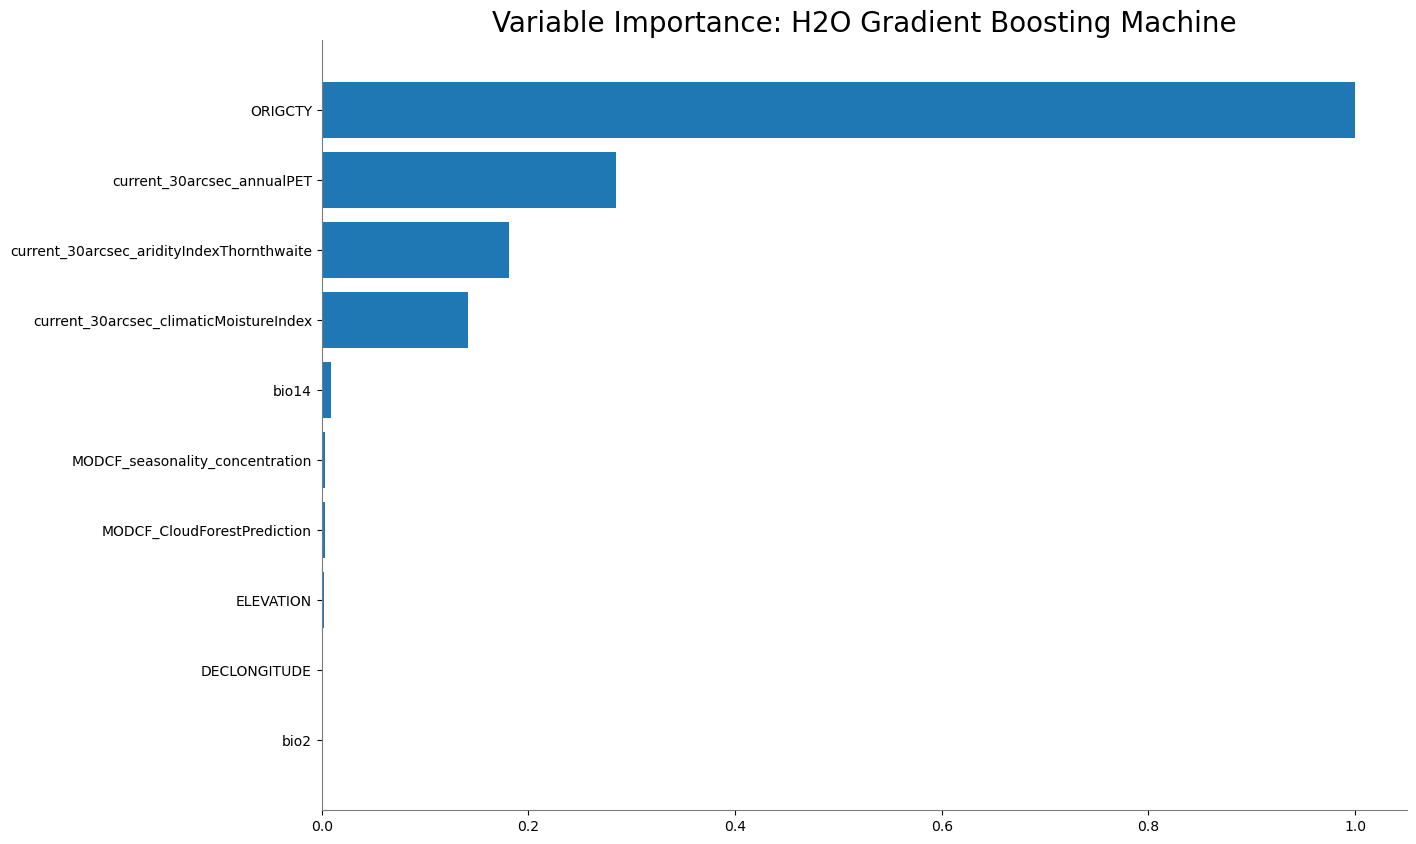

<Figure size 640x480 with 0 Axes>

In [15]:
# Mejor modelo
best_model = aml.leader
print(best_model.model_id)

# Importancia de variables
best_model.varimp_plot()


In [16]:
# Guardar leaderboard
h2o.export_file(lb, "automl_resultados.csv", force=True)

# Guardar el modelo
model_path = h2o.save_model(model=best_model, path="best_model_h2o", force=True)
print("Modelo guardado en:", model_path)


Export File progress: |██████████████████████████████████████████████████████████| (done) 100%
Modelo guardado en: C:\Users\guill\Documents\Introduccion_Accesiones\best_model_h2o\GBM_grid_1_AutoML_1_20251103_202948_model_1


In [5]:
# Asegurar tipo categórico en todo el dataset
y = "Resistencia_Sequía"
hf[y] = hf[y].asfactor()

# Confirmar tipo
print(hf.types)


NameError: name 'hf' is not defined

In [19]:
# Dividir en entrenamiento y prueba
train, test = hf.split_frame(ratios=[0.7], seed=42)


In [21]:
# Asegurar que sea numérica en todo el dataset
hf["Resistencia_Sequía"] = hf["Resistencia_Sequía"].asnumeric()

# Dividir
train, test = hf.split_frame(ratios=[0.7], seed=42)

# Evaluar el modelo
perf = best_model.model_performance(test_data=test)

# Mostrar métricas
print("RMSE:", perf.rmse())
print("MAE:", perf.mae())
print("R²:", perf.r2())


RMSE: 0.0016851007192893869
MAE: 0.0002614278432876276
R²: 0.9999827751477491


In [22]:
#verificanco si hay overftting
train_perf = best_model.model_performance(train)
test_perf = best_model.model_performance(test)

print("TRAIN R²:", train_perf.r2())
print("TEST R²:", test_perf.r2())


TRAIN R²: 0.999991163190918
TEST R²: 0.9999827751477491


In [23]:
import pandas as pd

# Suponiendo que el índice de aridez es menor en zonas más secas
q25 = df["current_30arcsec_aridityIndexThornthwaite"].quantile(0.25)
q75 = df["current_30arcsec_aridityIndexThornthwaite"].quantile(0.75)

def clasificar_resistencia(valor):
    if valor <= q25:
        return 1  # Resistente a sequía
    elif valor >= q75:
        return 0  # No resistente
    else:
        return None  # intermedios (opcional)

df["Resistencia_Sequía"] = df["current_30arcsec_aridityIndexThornthwaite"].apply(clasificar_resistencia)


In [24]:
import h2o
from h2o.automl import H2OAutoML

h2o.init()
hf = h2o.H2OFrame(df)

hf["Resistencia_Sequía"] = hf["Resistencia_Sequía"].asfactor()

train, test = hf.split_frame(ratios=[0.7], seed=42)

aml = H2OAutoML(max_models=15, seed=42, balance_classes=True)
aml.train(x=[c for c in hf.columns if c != "Resistencia_Sequía"], 
          y="Resistencia_Sequía", 
          training_frame=train)

leader = aml.leader
perf = leader.model_performance(test_data=test)

#print("AUC:", perf.auc())
print("Accuracy:", perf.accuracy()[0][1])
print("Precision:", perf.precision()[0][1])
print("Recall:", perf.recall()[0][1])
print("F1 Score:", perf.F1()[0][1])


Checking whether there is an H2O instance running at http://localhost:54321. connected.
Please download and install the latest version from: https://h2o-release.s3.amazonaws.com/h2o/latest_stable.html


H2O_cluster_uptime:,23 mins 55 secs
H2O_cluster_timezone:,America/Bogota
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.7
H2O_cluster_version_age:,7 months and 7 days
H2O_cluster_name:,H2O_from_python_guill_o7uhkx
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,15.92 Gb
H2O_cluster_total_cores:,16
H2O_cluster_allowed_cores:,16
H2O_cluster_status:,"locked, healthy"


Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
AutoML progress: |█
20:52:42.782: AutoML: XGBoost is not available; skipping it.
20:52:42.790: _train param, Dropping bad and constant columns: [DOI]

███████
20:54:29.354: _train param, Dropping bad and constant columns: [DOI]
20:54:29.489: GBM_1_AutoML_2_20251103_205242 [GBM def_5] failed: java.lang.IllegalArgumentException: Error during sampling - too few points?
20:54:29.492: _train param, Dropping bad and constant columns: [DOI]
20:54:29.616: DRF_1_AutoML_2_20251103_205242 [DRF def_1] failed: java.lang.IllegalArgumentException: Error during sampling - too few points?
20:54:29.618: _train param, Dropping bad and constant columns: [DOI]
20:54:29.732: GBM_2_AutoML_2_20251103_205242 [GBM def_2] failed: java.lang.IllegalArgumentException: Error during sampling - too few points?
20:54:29.735: _train param, Dropping bad and constant columns: [DOI]
20:54:29.773: GBM_3_AutoML_2_20251103_205242 [G

AttributeError: type object 'MetricsBase' has no attribute 'accuracy'

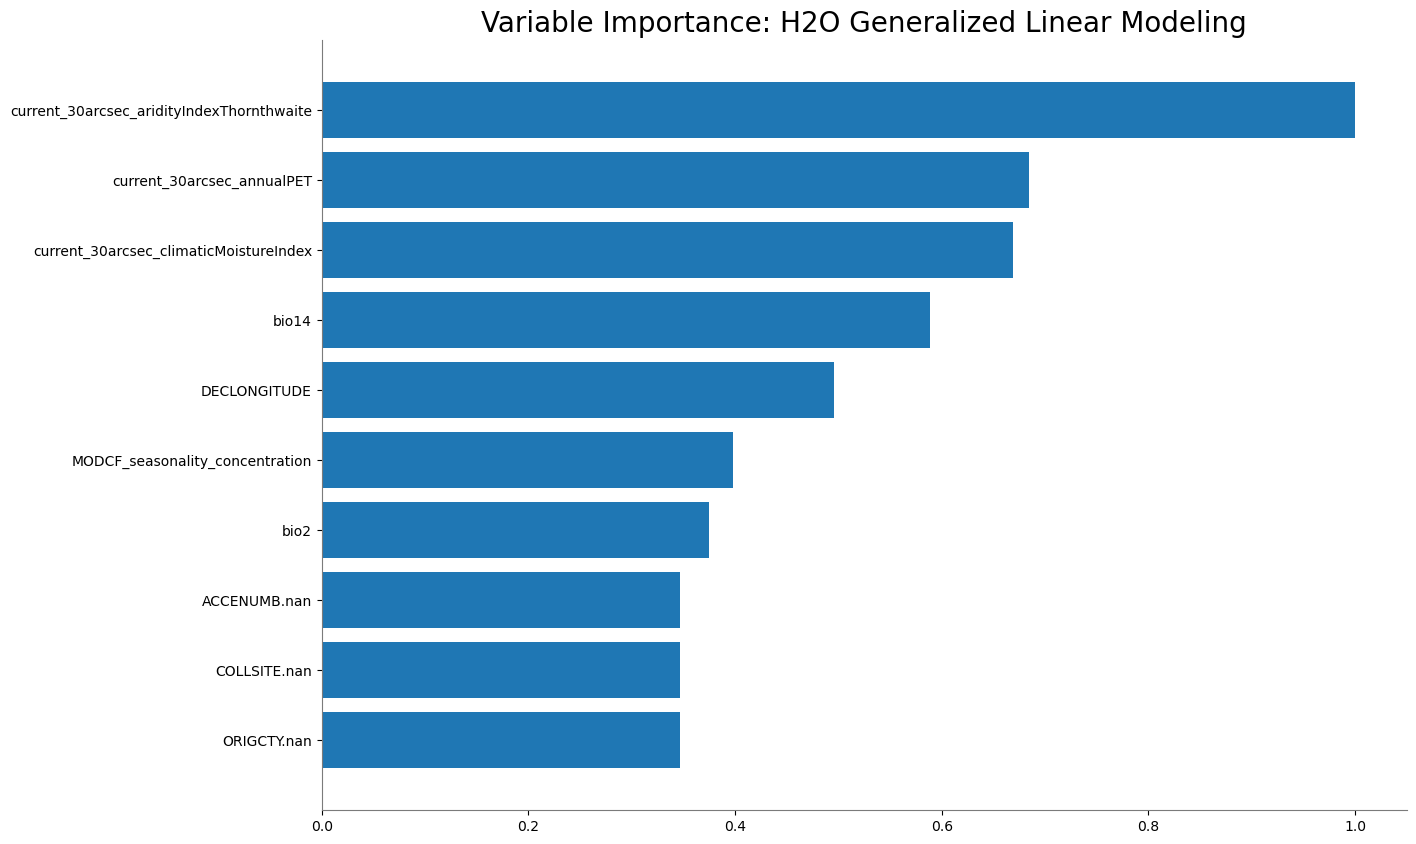

<Figure size 640x480 with 0 Axes>

In [25]:
import matplotlib.pyplot as plt

leader.varimp_plot(num_of_features=10)


In [26]:
varimp = leader.varimp(use_pandas=True)
varimp.to_csv("importancia_variables_h2o.csv", index=False)


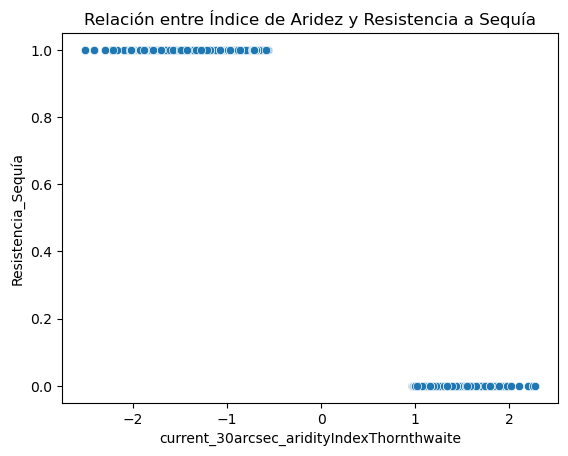

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(x="current_30arcsec_aridityIndexThornthwaite", 
                y="Resistencia_Sequía", data=df)
plt.title("Relación entre Índice de Aridez y Resistencia a Sequía")
plt.show()


In [29]:
# Obtener el leaderboard completo
lb = aml.leaderboard
lb.head(rows=10)  # Mostrar los 10 primeros

# Guardar en CSV para tu informe
lb.as_data_frame().to_csv("leaderboard_modelos_h2o.csv", index=False)


C:\Users\guill\miniconda3\envs\python_env\Lib\site-packages\h2o\frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


In [30]:
lb = aml.leaderboard
lb.head(rows=10)


model_id,mean_per_class_error,logloss,rmse,mse
GLM_1_AutoML_2_20251103_205242,0.557036,0.48465,0.400689,0.160552


**************************************************************************
***********************************************************************************

In [91]:
# Cargar los datasets
df_principal = pd.read_csv("dataset_reducido_no_colineal.csv")
df_variables = pd.read_csv("dataset_limpio_estandarizado.csv")

# Verificar columnas clave
print("Columnas en dataset principal:", len(df_principal.columns))
print("Columnas en dataset principal:", df_principal.columns.tolist())
print("Columnas en dataset adicional:", df_variables.columns.tolist())


Columnas en dataset principal: 25
Columnas en dataset principal: ['DOI', 'ACCENUMB', 'CURATION', 'GENUS', 'SPECIES', 'GRIN_NAME', 'SAMPSTAT', 'ORIGCTY', 'COLLSITE', 'DECLONGITUDE', 'ELEVATION', 'MODCF_CloudForestPrediction', 'MODCF_seasonality_concentration', 'current_30arcsec_aridityIndexThornthwaite', 'CRFVOL_M_sl1', 'BDRICM_M', 'PHIKCL_M_sl1', 'BDRLOG_M', 'SLGWRB', 'ACDWRB_M_ss', 'bio14', 'bio18', 'bio19', 'bio2', 'bio9']
Columnas en dataset adicional: ['DOI', 'ACCENUMB', 'CURATION', 'GENUS', 'SPECIES', 'GRIN_NAME', 'SAMPSTAT', 'ORIGCTY', 'COLLSITE', 'DECLATITUDE', 'DECLONGITUDE', 'ELEVATION', 'MODCF_CloudForestPrediction', 'MODCF_meanannual', 'MODCF_seasonality_concentration', 'current_30arcsec_annualPET', 'current_30arcsec_aridityIndexThornthwaite', 'current_30arcsec_climaticMoistureIndex', 'current_30arcsec_continentality', 'AWCh1_M_sl1', 'AWCh1_M_sl2', 'AWCh1_M_sl3', 'AWCh1_M_sl4', 'AWCh1_M_sl5', 'AWCh1_M_sl6', 'AWCh1_M_sl7', 'AWCh2_M_sl1', 'AWCh2_M_sl2', 'AWCh2_M_sl3', 'AWCh2_M

In [92]:
# Fusionar por la columna común
df_newcolumns = pd.merge(df_principal, df_variables[["ACCENUMB", "current_30arcsec_annualPET", "current_30arcsec_climaticMoistureIndex", "bio12",   # precipitación anual
    "bio15", "bio1", "bio5","bio6", "PHIHOX_M_sl1", "PHIHOX_M_sl2", "PHIHOX_M_sl3",
    "SLTPPT_M_sl1", "SLTPPT_M_sl2", "SLTPPT_M_sl3", "CLYPPT_M_sl1", "CLYPPT_M_sl2", "CLYPPT_M_sl3"]], on="ACCENUMB", how="left")

# Confirmar incorporación
print(df_newcolumns.shape)
#print(df_newcolumns[[ "bio18", "bio14"]].head())


(16797, 41)


In [93]:
# Verificar valores faltantes
print(df_newcolumns[["current_30arcsec_annualPET", "current_30arcsec_climaticMoistureIndex", "bio12",   # precipitación anual
    "bio14", "bio15", "bio18", "bio1", "bio5","bio6", "PHIHOX_M_sl1", "PHIHOX_M_sl2", "PHIHOX_M_sl3",
    "SLTPPT_M_sl1", "SLTPPT_M_sl2", "SLTPPT_M_sl3", "CLYPPT_M_sl1", "CLYPPT_M_sl2", "CLYPPT_M_sl3"]].isna().sum())


current_30arcsec_annualPET                5461
current_30arcsec_climaticMoistureIndex    5461
bio12                                     5461
bio14                                     5461
bio15                                     5461
bio18                                     5461
bio1                                      5461
bio5                                      5461
bio6                                      5461
PHIHOX_M_sl1                              5461
PHIHOX_M_sl2                              5461
PHIHOX_M_sl3                              5461
SLTPPT_M_sl1                              5461
SLTPPT_M_sl2                              5461
SLTPPT_M_sl3                              5461
CLYPPT_M_sl1                              5461
CLYPPT_M_sl2                              5461
CLYPPT_M_sl3                              5461
dtype: int64


In [94]:
# Imputar valores faltantes con la media de cada columna
for col in ["current_30arcsec_annualPET", "current_30arcsec_climaticMoistureIndex", "bio12",   # precipitación anual
    "bio14", "bio15", "bio18", "bio1", "bio5","bio6", "PHIHOX_M_sl1", "PHIHOX_M_sl2", "PHIHOX_M_sl3",
    "SLTPPT_M_sl1", "SLTPPT_M_sl2", "SLTPPT_M_sl3", "CLYPPT_M_sl1", "CLYPPT_M_sl2", "CLYPPT_M_sl3"]:
    df_newcolumns[col] = df_newcolumns[col].fillna(df_newcolumns[col].mean())

# Verificar que ya no haya valores NaN
print(df_newcolumns[["current_30arcsec_annualPET", "current_30arcsec_climaticMoistureIndex", "bio12",   # precipitación anual
    "bio14", "bio15", "bio18", "bio1", "bio5","bio6", "PHIHOX_M_sl1", "PHIHOX_M_sl2", "PHIHOX_M_sl3",
    "SLTPPT_M_sl1", "SLTPPT_M_sl2", "SLTPPT_M_sl3", "CLYPPT_M_sl1", "CLYPPT_M_sl2", "CLYPPT_M_sl3"]].isna().sum())

current_30arcsec_annualPET                0
current_30arcsec_climaticMoistureIndex    0
bio12                                     0
bio14                                     0
bio15                                     0
bio18                                     0
bio1                                      0
bio5                                      0
bio6                                      0
PHIHOX_M_sl1                              0
PHIHOX_M_sl2                              0
PHIHOX_M_sl3                              0
SLTPPT_M_sl1                              0
SLTPPT_M_sl2                              0
SLTPPT_M_sl3                              0
CLYPPT_M_sl1                              0
CLYPPT_M_sl2                              0
CLYPPT_M_sl3                              0
dtype: int64


In [95]:

# Suponiendo que el índice de aridez es menor en zonas más secas
q25 = df_newcolumns["current_30arcsec_aridityIndexThornthwaite"].quantile(0.25)
q75 = df_newcolumns["current_30arcsec_aridityIndexThornthwaite"].quantile(0.75)

def clasificar_resistencia(valor):
    if valor <= q25:
        return 1  # Resistente a sequía
    elif valor >= q75:
        return 0  # No resistente
    else:
        return None  # intermedios (opcional)

df_newcolumns["Resistencia_Sequia"] = df_newcolumns["current_30arcsec_aridityIndexThornthwaite"].apply(clasificar_resistencia)


In [96]:
# ============================================================
# 🧹 Limpieza robusta de la variable objetivo
# ============================================================

# Ver valores únicos antes de limpiar
print("Valores únicos antes de limpieza:")
print(df_newcolumns["Resistencia_Sequia"].unique())

# Reemplazar valores no numéricos o vacíos por NaN
df_newcolumns["Resistencia_Sequia"] = df_newcolumns["Resistencia_Sequia"].replace(
    [" ", "NA", "NaN", "nan", "?", "", None, np.inf, -np.inf],
    np.nan
)

# Mostrar cuántos NaN hay
print("\nCantidad de NaN:", df_newcolumns["Resistencia_Sequia"].isna().sum())

# Si hay pocos NaN, los rellenamos con 0 (no resistente)
df_newcolumns["Resistencia_Sequia"] = df_newcolumns["Resistencia_Sequia"].fillna(0)

# Convertir a entero (0 o 1)
df_newcolumns["Resistencia_Sequia"] = df_newcolumns["Resistencia_Sequia"].astype(int)

# Confirmar limpieza
print("\nConteo final de clases:")
print(df_newcolumns["Resistencia_Sequia"].value_counts())


Valores únicos antes de limpieza:
[nan  0.  1.]

Cantidad de NaN: 11112

Conteo final de clases:
Resistencia_Sequia
0    13962
1     2835
Name: count, dtype: int64


In [97]:
df_newcolumns.to_csv("dataset_con_variables_nuevas_agregadas.csv", index=False)
print("Dataset final guardado como 'dataset_con_variables_nuevas_agregadas.csv'")


Dataset final guardado como 'dataset_con_variables_nuevas_agregadas.csv'


In [98]:
assert set(df_newcolumns["Resistencia_Sequia"].unique()).issubset({0, 1}), \
    "Aún hay valores distintos de 0 y 1"


In [85]:


# Inicializar clúster H2O
h2o.init()

# Cargar el dataset
df = pd.read_csv("dataset_con_variables_nuevas_agregadas.csv")

# Revisar valores únicos en la variable objetivo
print(df["Resistencia_Sequía"].unique())

# Reemplazar valores erróneos
df["Resistencia_Sequía"] = df["Resistencia_Sequía"].replace([" ", "NA", "?", "nan", None], 0)
df["Resistencia_Sequía"] = df["Resistencia_Sequía"].astype(int)

# Confirmar limpieza
print(df["Resistencia_Sequía"].value_counts())

# Convertir a H2OFrame
hf = H2OFrame(df)

# Convertir la variable objetivo a factor (binaria)
hf["Resistencia_Sequía"] = hf["Resistencia_Sequía"].asfactor()

# Dividir en entrenamiento y prueba
train, test = hf.split_frame(ratios=[0.8], seed=123)

# Entrenar AutoML
aml = H2OAutoML(max_models=10, seed=42, balance_classes=True)
aml.train(x=[c for c in hf.columns if c != "Resistencia_Sequía"], y="Resistencia_Sequía", training_frame=train)

# Evaluar rendimiento
best_model = aml.leader
perf = best_model.model_performance(test_data=test)
print(perf)


Checking whether there is an H2O instance running at http://localhost:54321. connected.
Please download and install the latest version from: https://h2o-release.s3.amazonaws.com/h2o/latest_stable.html


H2O_cluster_uptime:,1 hour 38 mins
H2O_cluster_timezone:,America/Bogota
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.7
H2O_cluster_version_age:,7 months and 7 days
H2O_cluster_name:,H2O_from_python_guill_o7uhkx
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,15.67 Gb
H2O_cluster_total_cores:,16
H2O_cluster_allowed_cores:,16
H2O_cluster_status:,"locked, healthy"


[0 1]
Resistencia_Sequía
0    13962
1     2835
Name: count, dtype: int64
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
AutoML progress: |█
22:06:55.558: AutoML: XGBoost is not available; skipping it.
22:06:55.561: _train param, Dropping bad and constant columns: [DOI]

██
22:07:02.99: _train param, Dropping bad and constant columns: [DOI]

███
22:07:48.852: _train param, Dropping bad and constant columns: [DOI]
22:07:52.897: _train param, Dropping bad and constant columns: [DOI]

███
22:08:21.16: _train param, Dropping bad and constant columns: [DOI]

███
22:09:01.72: _train param, Dropping bad and constant columns: [DOI]

█
22:09:42.97: _train param, Dropping bad and constant columns: [DOI]

█
22:09:47.511: _train param, Dropping bad and constant columns: [DOI]

███
22:10:24.56: _train param, Dropping bad and constant columns: [DOI]

████
22:11:33.29: _train param, Dropping unused columns: [DOI]
22:11:37.428: _train param, Dropping unus

In [99]:
import h2o
from h2o.automl import H2OAutoML
h2o.init()

# Cargar dataset limpio
hf = h2o.import_file("dataset_con_variables_nuevas_agregadas.csv")

# Asegurarse de que la variable sea binaria categórica
hf["Resistencia_Sequia"] = hf["Resistencia_Sequia"].asfactor()

# Variables predictoras
x = [c for c in hf.columns if c != "Resistencia_Sequia"]
y = "Resistencia_Sequia"

# Entrenar AutoML con validación cruzada (5 folds)
aml_cv = H2OAutoML(
    max_models=10,
    seed=42,
    nfolds=5,
    balance_classes=True,
    sort_metric="AUC",
    verbosity="info"
)
aml_cv.train(x=x, y=y, training_frame=hf)

# Mejor modelo
best_model_cv = aml_cv.leader
print(best_model_cv.model_performance())


Checking whether there is an H2O instance running at http://localhost:54321. connected.
Please download and install the latest version from: https://h2o-release.s3.amazonaws.com/h2o/latest_stable.html


H2O_cluster_uptime:,2 hours 1 min
H2O_cluster_timezone:,America/Bogota
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.7
H2O_cluster_version_age:,7 months and 7 days
H2O_cluster_name:,H2O_from_python_guill_o7uhkx
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,15.51 Gb
H2O_cluster_total_cores:,16
H2O_cluster_allowed_cores:,16
H2O_cluster_status:,"locked, healthy"


Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
AutoML progress: |█
22:29:49.696: Project: AutoML_5_20251103_222949
22:29:49.697: Setting stopping tolerance adaptively based on the training frame: 0.007715856444616493
22:29:49.697: Build control seed: 42
22:29:49.698: training frame: Frame key: AutoML_5_20251103_222949_training_py_35_sid_9cdc    cols: 42    rows: 16797  chunks: 64    size: 5580999  checksum: -4338751376610341983
22:29:49.698: validation frame: NULL
22:29:49.698: leaderboard frame: NULL
22:29:49.698: blending frame: NULL
22:29:49.698: response column: Resistencia_Sequia
22:29:49.698: fold column: null
22:29:49.698: weights column: null
22:29:49.698: AutoML: XGBoost is not available; skipping it.
22:29:49.698: Loading execution steps: [{XGBoost : [def_2 (1g, 10w), def_1 (2g, 10w), def_3 (3g, 10w), grid_1 (4g, 90w), lr_search (7g, 30w)]}, {GLM : [def_1 (1g, 10w)]}, {DRF : [def_1 (2g, 10w), XRT (3g, 10w)]}, {GBM : [def_5 (1g, 

In [65]:
# ============================================================
# 4️⃣ Ejecutar AutoML con múltiples modelos
# ============================================================

aml = H2OAutoML(
    max_models=15,           # prueba varios modelos
    max_runtime_secs=1200,   # 20 minutos máximo
    seed=42,
    balance_classes=True,
    sort_metric="AUC"        # prioriza modelos con mejor discriminación binaria
)

aml.train(x=features, y=target, training_frame=train)


AutoML progress: |█
21:50:47.36: AutoML: XGBoost is not available; skipping it.

██
21:50:55.728: GBM_1_AutoML_3_20251103_215047 [GBM def_5] failed: java.lang.IllegalArgumentException: Error during sampling - too few points?
21:50:55.819: DRF_1_AutoML_3_20251103_215047 [DRF def_1] failed: java.lang.IllegalArgumentException: Error during sampling - too few points?
21:50:55.903: GBM_2_AutoML_3_20251103_215047 [GBM def_2] failed: java.lang.IllegalArgumentException: Error during sampling - too few points?
21:50:55.981: GBM_3_AutoML_3_20251103_215047 [GBM def_3] failed: java.lang.IllegalArgumentException: Error during sampling - too few points?
21:50:56.10: GBM_4_AutoML_3_20251103_215047 [GBM def_4] failed: java.lang.IllegalArgumentException: Error during sampling - too few points?
21:50:56.27: XRT_1_AutoML_3_20251103_215047 [DRF XRT (Extremely Randomized Trees)] failed: java.lang.IllegalArgumentException: Error during sampling - too few points?
21:50:56.45: GBM_5_AutoML_3_20251103_215047 [

Model Details
=============
H2OGeneralizedLinearEstimator : Generalized Linear Modeling
Model Key: GLM_1_AutoML_3_20251103_215047


GLM Model: summary
    family       link         regularization               lambda_search                                                                    number_of_predictors_total    number_of_active_predictors    number_of_iterations    training_frame
--  -----------  -----------  ---------------------------  -------------------------------------------------------------------------------  ----------------------------  -----------------------------  ----------------------  ------------------------------------------------
    multinomial  multinomial  Ridge ( lambda = 2.269E-5 )  nlambda = 30, lambda.max = 22.694, lambda.min = 2.269E-5, lambda.1se = 2.269E-5  80                            76                             73                      AutoML_3_20251103_215047_training_py_22_sid_bae3

ModelMetricsMultinomialGLM: glm
** Reported on train data. **

MSE: 0.006331283207792795
RMSE: 0.07956936098645505
LogLoss: 0.028645465561115007
Null degrees of freedom: 13487
Residual degrees of freedom: 13408
Null deviance: 23602.35419805875
Residual deviance: 772.7400789766393
AUC table was not computed: it is either disabled (model parameter 'auc_type' was set to AUTO or NONE) or the domain size exceeds the limit (maximum is 50 domains).
AUCPR table was not computed: it is either disabled (model parameter 'auc_type' was set to AUTO or NONE) or the domain size exceeds the limit (maximum is 50 domains).

Confusion Matrix: Row labels: Actual class; Column labels: Predicted class
0.0    1.0    Resistencia_Sequía    nan    Error       Rate
-----  -----  --------------------  -----  ----------  -----------
2277   0      0                     10     0.00437254  10 / 2.287
0      2260   0                     14     0.00615655  14 / 2.274
0      0      0                     1      1           1 / 1
19     14     0                     8893   0.00369706  33 / 8.926
2296   2274   0                     8918   0.00430012  58 / 13.488

Top-4 Hit Ratios: 
k    hit_ratio
---  -----------
1    0.9957
2    1
3    1
4    1

ModelMetricsMultinomialGLM: glm
** Reported on cross-validation data. **

MSE: 0.007468253288025948
RMSE: 0.08641905627826509
LogLoss: 0.03427760539533718
Null degrees of freedom: 13487
Residual degrees of freedom: 13427
Null deviance: Infinity
Residual deviance: 979.2131905811026
AUC table was not computed: it is either disabled (model parameter 'auc_type' was set to AUTO or NONE) or the domain size exceeds the limit (maximum is 50 domains).
AUCPR table was not computed: it is either disabled (model parameter 'auc_type' was set to AUTO or NONE) or the domain size exceeds the limit (maximum is 50 domains).

Confusion Matrix: Row labels: Actual class; Column labels: Predicted class
0.0    1.0    Resistencia_Sequía    nan    Error       Rate
-----  -----  --------------------  -----  ----------  -----------
2276   0      0                     11     0.00480979  11 / 2.287
0      2253   0                     21     0.00923483  21 / 2.274
0      0      0                     1      1           1 / 1
29     20     0                     8877   0.00548958  49 / 8.926
2305   2273   0                     8910   0.00607948  82 / 13.488

Top-4 Hit Ratios: 
k    hit_ratio
---  -----------
1    0.99392
2    0.999926
3    0.999926
4    1

Cross-Validation Metrics Summary: 
                         mean        sd           cv_1_valid    cv_2_valid    cv_3_valid    cv_4_valid    cv_5_valid
-----------------------  ----------  -----------  ------------  ------------  ------------  ------------  ------------
accuracy                 0.993921    0.00229344   0.996664      0.990734      0.992587      0.994809      0.994809
aic                      nan         0            nan           nan           nan           nan           nan
auc                      nan         0            nan           nan           nan           

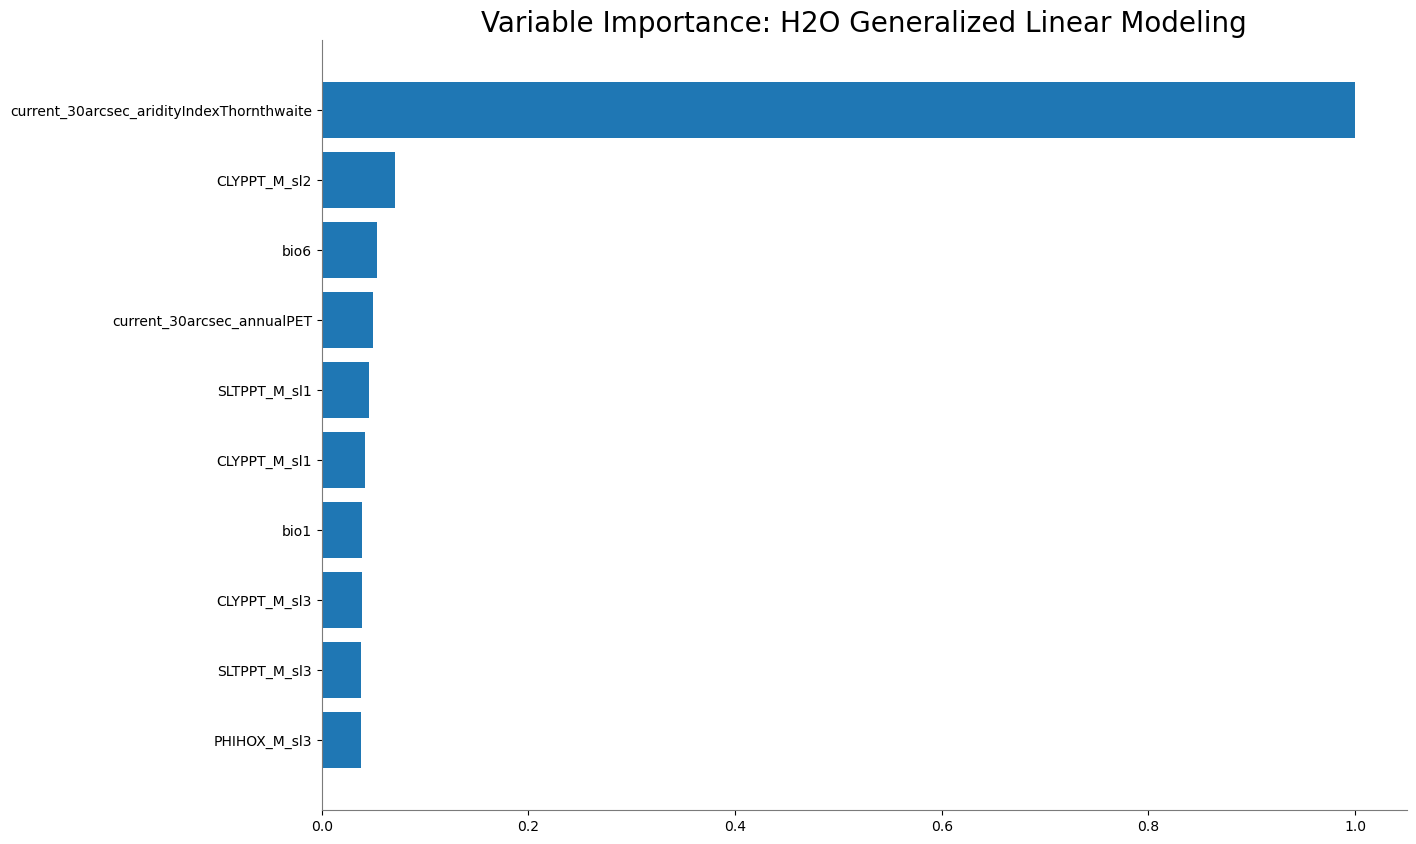

<Figure size 640x480 with 0 Axes>

In [67]:
# ============================================================
# 6️⃣ Variables más influyentes
# ============================================================

varimp_plot = best_model.varimp_plot()


In [69]:
# Ver qué métricas tiene el objeto de rendimiento
print(perf)


ModelMetricsMultinomialGLM: glm
** Reported on test data. **

MSE: 0.0071815444094115366
RMSE: 0.08474399335298954
LogLoss: 0.03048699046451402
Null degrees of freedom: 3309
Residual degrees of freedom: 3230
Null deviance: 5800.507365386407
Residual deviance: 201.82387687508282
AUC table was not computed: it is either disabled (model parameter 'auc_type' was set to AUTO or NONE) or the domain size exceeds the limit (maximum is 50 domains).
AUCPR table was not computed: it is either disabled (model parameter 'auc_type' was set to AUTO or NONE) or the domain size exceeds the limit (maximum is 50 domains).

Confusion Matrix: Row labels: Actual class; Column labels: Predicted class
0.0    1.0    Resistencia_Sequía    nan    Error       Rate
-----  -----  --------------------  -----  ----------  ----------
560    0      0                     3      0.0053286   3 / 563
0      558    0                     3      0.00534759  3 / 561
0      0      0                     0      nan         0 / 0


In [68]:
# ============================================================
# 7️⃣ Evaluar rendimiento del modelo
# ============================================================

perf = best_model.model_performance(test_data=test)

print("AUC:", perf.auc())
print("Accuracy:", perf.accuracy()[0][1])
print("Precision:", perf.precision()[0][1])
print("Recall:", perf.recall()[0][1])
print("F1 Score:", perf.F1()[0][1])


AUC: NaN


AttributeError: type object 'MetricsBase' has no attribute 'accuracy'